# Actor-Critic Methods in Reinforcement Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement actor–critic algorithms
- Combine policy and value learning

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 2, lesson 02 "Gradients and Multivariable Calculus" — the actor's update is a gradient of expected return with respect to policy parameters; the critic is a second learned function whose only job is to make that gradient estimate less noisy.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces the **actor-critic** idea: one part of the system chooses actions, and another estimates how good states or actions are.

Students will see why combining a policy learner with a value estimator can reduce variance and make learning more stable.

Why this matters: actor-critic methods are the foundation of many practical RL algorithms used in continuous control and modern AI systems.

This lesson is a bridge from basic policy gradients to stronger methods like PPO.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: AlphaStar, and why the critic had to exist

StarCraft II is the problem that policy gradients alone could not survive. A match lasts tens of
thousands of decisions, the map is partly hidden, and the only unambiguous reward — win or lose —
arrives once, at the end. Scale REINFORCE's whole-episode return to that horizon and the variance
swamps everything.

Vinyals et al. ("Grandmaster level in StarCraft II using multi-agent reinforcement learning",
*Nature* **575**, 2019) built AlphaStar as an **actor-critic**: an actor producing the action
distribution, and a learned value function — the critic — estimating how the game is going *right
now*, so each action could be credited against the current position rather than against the final
result thirty minutes later. Bootstrapped from 971,000 human replays and trained in a self-play
league, AlphaStar reached **Grandmaster level for all three races and ranked above 99.8% of active
players on Battle.net**, playing on the public server under the same conditions as humans.

**What goes wrong without this.** REINFORCE waits for the episode to end and then attributes the
whole return to every action in it — including the good moves in a lost game and the bad moves in a
won one. The critic replaces that lump sum with a per-step judgement: "this action left you better
off than expected", which is the TD error of Unit 2, lesson 02, now used as a training signal for a
policy. Look at the two curves this notebook prints and remember what is being traded: less variance,
in exchange for a critic that can be wrong.

**Read this notebook honestly.** The actor-critic section below runs a **three-episode** demonstration
(rewards 21.0, 28.0, 48.0) — it shows you the architecture and the update, not a result. Three
episodes cannot tell you whether anything was learned. The
contrast run afterwards is a full 500-episode REINFORCE. Do not read the two side by side as a
comparison; the comparison is not run here.


## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Everything You Need To Master Actor Critic Methods"**:
[Watch on YouTube](https://www.youtube.com/watch?v=LawaN3BdI00)

Why this pick:
- beginner-friendly structure.
- Explains the separate jobs of the actor and critic before showing implementation.
- Good support for students moving beyond pure value methods.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Actor: learns the policy and chooses actions.
- Critic: estimates value information to guide the actor.
- Advantage-like signal: tells whether an action was better than expected.
- Shared loop: both learn from the same experience.
- Variance reduction: one reason actor-critic can be more stable than pure policy gradients.

### Quick Check
- What does the actor learn?
- What does the critic learn?
- Why can this be more stable than pure policy gradients?
- Why is the critic useful even though it does not choose the action?

### Common Mistakes
- Swapping actor and critic roles.
- Thinking the critic chooses actions.
- Forgetting they optimize different objectives.
- Thinking actor-critic is a totally different idea instead of a policy-gradient method with extra value guidance.


## Actor-Critic in Plain Language

Actor-critic methods answer a practical problem in deep RL:

`Can we keep the flexibility of policy gradients while giving the policy better feedback than raw returns alone?`

### The actor

The actor is the part that decides:

`What action should I take?`

So it learns the policy.

### The critic

The critic is the part that estimates how good the current situation or action is.
It does not choose the action. It provides a learning signal.

### Why combine them?

Pure policy gradients can work, but they often have high variance.
The critic helps the actor learn with more informative feedback, which can make updates more stable and data-efficient.

### Memory rule

- actor -> acts
- critic -> critiques

That simple sentence often prevents the most common student confusion.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Install or import dependencies so later cells can run.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Pip progress lines and usually a confirmation that imports work.

**If you feel lost:** Fix any red install error before continuing—later cells assume this cell succeeded.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic-control]" torch numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import torch
# Load a library so you can use its ready-made functions and types below.
import torch.nn as nn
# Load a library so you can use its ready-made functions and types below.
import torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Actor-Critic Architecture


### Step Guide

**What this cell does:** PyTorch-heavy block (network, loss, or training step)—read shapes and prints first.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `ActorCritic` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class ActorCritic(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs_dim, act_dim.
    def __init__(self, obs_dim=4, act_dim=2):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.shared = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs_dim, 128),
            # Call a PyTorch API (tensor/module/training-related).
            nn.ReLU(),
        # Close the parentheses opened earlier (end this function call / grouping).
        )
        # Save a value in a name so the next lines can read it.
        self.actor_head = nn.Linear(128, act_dim)
        # Another assignment—same idea: store a value for the lines below.
        self.critic_head = nn.Linear(128, 1)

    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x):
        # Save a value in a name so the next lines can read it.
        features = self.shared(x)
        # Create or update the greedy policy array (one int action id per state).
        policy_logits = self.actor_head(features)
        # Save a value in a name so the next lines can read it.
        state_value = self.critic_head(features)
        # Send a value back to whoever called this function.
        return policy_logits, state_value


## Part 2: Training Loop


### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `train_actor_critic` (what it does): Minimal demonstration loop structure for actor-critic training.
def train_actor_critic(env_name='CartPole-v1', episodes=5, seed=0):
    """Minimal demonstration loop structure for actor-critic training."""
    # Pin every source of randomness so this demonstration prints the SAME rewards on every
    # machine: torch.manual_seed fixes both the network's starting weights and the action
    # sampling below, and the per-episode reset seed fixes where the pole starts.
    # WHY it matters: the episode rewards from this cell are quoted in this notebook's text.
    # An unseeded demo turns those quoted numbers into a lie the first time anyone re-runs it.
    torch.manual_seed(seed)
    # Save a value in a name so the next lines can read it.
    env = gym.make(env_name)
    # Another assignment—same idea: store a value for the lines below.
    model = ActorCritic()
    # Another assignment—same idea: store a value for the lines below.
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Start a loop: repeat the indented block once per item in the sequence.
    for episode in range(episodes):
        # Save a value in a name so the next lines can read it.
        # A different seed per episode: reproducible, but not the same start state every time.
        obs, _ = env.reset(seed=seed + episode)
        # Another assignment—same idea: store a value for the lines below.
        total_reward = 0
        # Start a loop: repeat the indented block once per item in the sequence.
        for _ in range(200):
            # Save a value in a name so the next lines can read it.
            obs_t = torch.tensor(obs).float().unsqueeze(0)
            # Another assignment—same idea: store a value for the lines below.
            logits, value = model(obs_t)
            # Another assignment—same idea: store a value for the lines below.
            dist = torch.distributions.Categorical(logits=logits)
            # Another assignment—same idea: store a value for the lines below.
            action = dist.sample()
            # Another assignment—same idea: store a value for the lines below.
            next_obs, reward, done, trunc, _ = env.step(action.item())

            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                _, next_value = model(torch.tensor(next_obs).float().unsqueeze(0))
            # Compute one Bellman backup candidate: reward + gamma * V(next_state).
            target = reward + 0.99 * next_value.item() * (0 if (done or trunc) else 1)
            # Save a value in a name so the next lines can read it.
            advantage = target - value.item()

            # Another assignment—same idea: store a value for the lines below.
            actor_loss = -dist.log_prob(action) * advantage
            # Another assignment—same idea: store a value for the lines below.
            critic_loss = (value.squeeze() - target) ** 2
            # Another assignment—same idea: store a value for the lines below.
            loss = actor_loss + critic_loss

            # Execute: optimizer.zero_grad()
            optimizer.zero_grad()
            # Execute: loss.backward()
            loss.backward()
            # Execute: optimizer.step()
            optimizer.step()

            # Save a value in a name so the next lines can read it.
            obs = next_obs
            # Another assignment—same idea: store a value for the lines below.
            total_reward += reward
            # If the condition is True, run the indented block under this line.
            if done or trunc:
                # Stop the loop completely and continue after the loop block.
                break
        # Show text or numbers in the cell output area under the code.
        print(f"Episode {episode + 1}: reward={total_reward}")

    # Execute: env.close()
    env.close()
    # Send a value back to whoever called this function.
    return model


# Save a value in a name so the next lines can read it.
_ = train_actor_critic(episodes=3)


Episode 1: reward=21.0
Episode 2: reward=28.0
Episode 3: reward=48.0


## CartPole step-through (GIF + slider)

Same **Gymnasium** loop as Unit 1, shown as **pixels**. Policy is **random** here for a stable demo; after you understand how your actor picks actions, try wiring this block to a greedy policy from `model` as an extension.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


12 frames | return=11.0 | term=True | trunc=False

objc[59091]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11c438138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11c9549c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59091]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11c438188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11c954a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59091]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11c437c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11c954a68). T

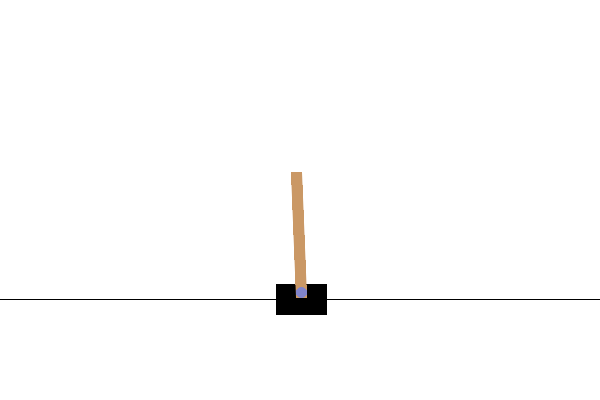

In [4]:
# Motion recap (optional visual): replay one CartPole episode as a GIF + step slider via the shared Course 09 helper.
# Why: watching the cart and pole move frame-by-frame connects the training numbers above to real behaviour.

%pip install ipywidgets pillow -q

import pathlib
import sys

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz

# Create the environment in rgb_array mode so every step can be captured as an image frame.
env_vis = gym.make("CartPole-v1", render_mode="rgb_array")


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def random_policy(obs, step):
    return int(env_vis.action_space.sample())


# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=100, seed=0
)
env_vis.close()

print(f"{len(frames)} frames | return={total_r:.1f} | term={term} | trunc={trunc}")
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="CartPole-v1 timestep")

## Real-World Applications

- **Robotics**: Continuous control (robot arm, walking)
- **Autonomous Vehicles**: Steering, acceleration control
- **Game AI**: Real-time strategy games
- **Finance**: Portfolio optimization

---

**End of Notebook**

## 🌍 Contrast Example — REINFORCE on CartPole

**Industry context:**
- Actor-critic methods belong to the same broad policy-optimization family as simpler policy-gradient methods
- Robotics and control systems often move from simple policy gradients toward actor-critic and PPO-style methods
- This example is included as a contrast, not as a claim that REINFORCE equals actor-critic

We implement **REINFORCE** on CartPole-v1 so students can contrast it with the actor-critic structure introduced earlier in the notebook.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward: 13.0


Episode  50 | Avg reward: 16.4
Episode 100 | Avg reward: 31.5


Episode 150 | Avg reward: 56.7


Episode 200 | Avg reward: 129.9


Episode 250 | Avg reward: 245.3


Episode 300 | Avg reward: 386.1


Episode 350 | Avg reward: 365.6


Episode 400 | Avg reward: 454.8


Episode 450 | Avg reward: 449.8


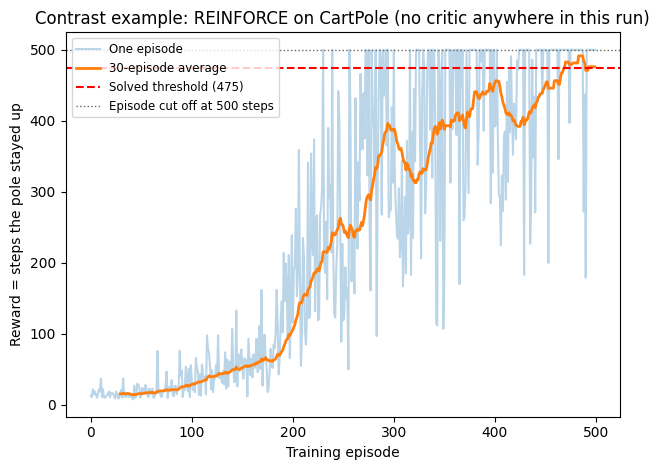

In [5]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Fix the random seeds (PyTorch draws the actions, so its seed decides the run) so this
# curve and the figures below it stay the ones the captions describe.
torch.manual_seed(42); np.random.seed(42)
# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')
# Seed the environment too, so the sequence of start states is the same on every run.
env.reset(seed=42); env.action_space.seed(42)

# Class `PolicyNet` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class PolicyNet(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(4, 128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy  = PolicyNet()
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy.parameters(), lr=2e-3)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; ep_rewards = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(500):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(500):
        # Save a value in a name so the next lines can read it.
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        # Another assignment—same idea: store a value for the lines below.
        dist   = torch.distributions.Categorical(probs)
        # Another assignment—same idea: store a value for the lines below.
        action = dist.sample()
        # Add one new item to the end of a list (the list grows in place).
        log_probs.append(dist.log_prob(action))
        # Save a value in a name so the next lines can read it.
        obs, r, done, trunc, _ = env.step(action.item())
        # Add one new item to the end of a list (the list grows in place).
        rewards_ep.append(r)
        # If the condition is True, run the indented block under this line.
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    G = 0; returns = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in reversed(rewards_ep):
        # Save a value in a name so the next lines can read it.
        G = r + GAMMA*G; returns.insert(0, G)
    # Another assignment—same idea: store a value for the lines below.
    returns = torch.tensor(returns).float()
    # Another assignment—same idea: store a value for the lines below.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    # Execute: opt.zero_grad(); loss.backward(); opt.step()
    opt.zero_grad(); loss.backward(); opt.step()
    # Add one new item to the end of a list (the list grows in place).
    ep_rewards.append(sum(rewards_ep))
    # If the condition is True, run the indented block under this line.
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

# Execute: env.close()
env.close()
# Save a value in a name so the next lines can read it.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
# Thin line: every single episode. The scatter is part of what this contrast is for.
plt.plot(ep_rewards, alpha=0.3, label="One episode")
# Thick line: the 30-episode average, placed at the last episode of each window.
plt.plot(np.arange(len(ma)) + 29, ma, lw=2, label="30-episode average")
# The score Gymnasium calls "solved" for CartPole-v1.
plt.axhline(475, color='red', linestyle='--', label="Solved threshold (475)")
# CartPole-v1 stops every episode at 500 steps, so the flat top is a ceiling, not a plateau.
plt.axhline(500, color='0.4', linestyle=':', lw=1, label="Episode cut off at 500 steps")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Contrast example: REINFORCE on CartPole (no critic anywhere in this run)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Training episode")
# Name the y-axis in words: on CartPole the reward IS the number of steps survived.
plt.ylabel("Reward = steps the pole stayed up")
# Legend goes top-left, the one corner of this plot with no data in it.
plt.legend(loc="upper left", fontsize=8.5); plt.tight_layout(); plt.show()


### 👁️ Read the figure

**What it shows.** A 500-episode REINFORCE run on CartPole — one faint blue point per episode, the thick
orange line its 30-episode average. There is **no critic in this run at all**. This is the contrast case, not
half of a race: as the "Real case" section says, the comparison is deliberately not run in this notebook, so
do not read this curve against the three-episode actor-critic smoke test above it.

**What to see.** The orange average climbs to the solved line, so plain policy gradient does learn this task.
Then look at the faint blue cloud around it: even late in training, individual episodes still fall far below
the average. That spread is what one whole-episode return per update buys you.

**What it proves.** It sets up the problem the critic is meant to solve. Every point on this plot was produced
by scaling the gradient with a number that depends on how the *whole episode* turned out. The next figure takes
one of these episodes apart and shows what that number actually says — and what a critic would say instead.

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Barto, A. G., Sutton, R. S. & Anderson, C. W. (1983). *Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problems*. IEEE Transactions on Systems, Man, and Cybernetics, 13, 834-846.
2. Williams, R. J. (1992). *Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning* (REINFORCE). Machine Learning, 8. <https://link.springer.com/article/10.1007/BF00992696>
3. Mnih, V., Badia, A. P., Mirza, M. et al. (2016). *Asynchronous Methods for Deep Reinforcement Learning* (A3C). ICML. <https://arxiv.org/abs/1602.01783>
4. Andrychowicz, M., Raichuk, A., Stańczyk, P. et al. (2020). *What Matters in On-Policy Reinforcement Learning? A Large-Scale Empirical Study*. arXiv:2006.05990. <https://arxiv.org/abs/2006.05990>
5. Rafailov, R., Sharma, A., Mitchell, E., Ermon, S., Manning, C. D., & Finn, C. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model*. arXiv preprint. <https://arxiv.org/abs/2305.18290> (removes the reward model and the reinforcement-learning loop entirely for preference data — no actor, no critic, no separate reward model)
6. Shao, Z., Wang, P., Zhu, Q., Xu, R., Song, J., Bi, X., Zhang, H., Zhang, M., Li, Y. K., Wu, Y., & Guo, D. (2024). *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models*. arXiv preprint. <https://arxiv.org/abs/2402.03300> (introduces GRPO, which drops the critic and uses the mean return of a group of sampled answers as the baseline)
"""))

## 📚 References

1. Barto, A. G., Sutton, R. S. & Anderson, C. W. (1983). *Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problems*. IEEE Transactions on Systems, Man, and Cybernetics, 13, 834-846.
2. Williams, R. J. (1992). *Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning* (REINFORCE). Machine Learning, 8. <https://link.springer.com/article/10.1007/BF00992696>
3. Mnih, V., Badia, A. P., Mirza, M. et al. (2016). *Asynchronous Methods for Deep Reinforcement Learning* (A3C). ICML. <https://arxiv.org/abs/1602.01783>
4. Andrychowicz, M., Raichuk, A., Stańczyk, P. et al. (2020). *What Matters in On-Policy Reinforcement Learning? A Large-Scale Empirical Study*. arXiv:2006.05990. <https://arxiv.org/abs/2006.05990>
5. Rafailov, R., Sharma, A., Mitchell, E., Ermon, S., Manning, C. D., & Finn, C. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model*. arXiv preprint. <https://arxiv.org/abs/2305.18290> (removes the reward model and the reinforcement-learning loop entirely for preference data — no actor, no critic, no separate reward model)
6. Shao, Z., Wang, P., Zhu, Q., Xu, R., Song, J., Bi, X., Zhang, H., Zhang, M., Li, Y. K., Wu, Y., & Guo, D. (2024). *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models*. arXiv preprint. <https://arxiv.org/abs/2402.03300> (introduces GRPO, which drops the critic and uses the mean return of a group of sampled answers as the baseline)


## 💬 Discuss

The actor-critic cell trained for **3 episodes** (21.0, 28.0, 48.0). The REINFORCE contrast trained
for 500, and its 50-episode average went **13.0 → 16.4 → 31.5 → 56.7 → 129.9 → 245.3 → 386.1 →
365.6 → 454.8 → 449.8** (episodes 0, 50, … 450). Argue these out.

1. Nothing in this notebook establishes that actor-critic beats REINFORCE. Design the experiment
   that would: what is held constant, how many seeds, what do you report, and what result would make
   you conclude "no meaningful difference"? Be specific enough that a classmate could run it.
2. REINFORCE's average slipped from 386.1 at episode 300 to 365.6 at 350 before reaching 454.8 at
   400. That wobble is mild on this seed — the standard complaint about REINFORCE is that its size
   varies wildly from seed to seed, which is exactly what a single run cannot show you. A critic is
   supposed to damp that. What could go wrong instead — describe a failure that a *bad* critic
   introduces which REINFORCE, having no critic, cannot suffer from.
3. AlphaStar's critic estimated "how is this game going" from partial information — the fog of war
   hides the opponent. Pick a business system where the equivalent is true (you cannot observe the
   thing that determines the outcome) and say what your critic would actually be estimating, and how
   you would know it was wrong.


## 📝 Summary

You learned that **Actor-Critic** combines a policy learner (the actor) with a value estimator (the critic) so each policy update is guided by the critic's estimate instead of the raw episode return. In the literature this baseline typically reduces the variance of the updates compared with plain REINFORCE — our 3-episode demo loop above is far too short to demonstrate that empirically; treat the 500-episode REINFORCE contrast as the training-scale reference point, not as a variance comparison. **PPO** can be understood as a later practical refinement built on this broader family of policy-optimization ideas.

### Step Guide

**What this cell does:** Puts the two learning signals side by side — the one REINFORCE uses and the one a critic would give — on the same real episodes.

**How to read it (weak Python OK):** The cell replays the trained policy for 30 episodes, trains the `ActorCritic` critic head from Part 1 on what it saw, and then draws both signals. No policy is trained here; nothing competes with anything.

**What to expect in the output:** Three printed lines of numbers, then one figure with two panels: one episode step by step on the left, all 30 episodes pooled on the right.

**If you feel lost:** You only need one sentence from this cell — the critic turns "how long did the episode last after this step" into "was this step better or worse than expected".

Collected 30 episodes, 14682 time steps in total.
REINFORCE signal (return still to come): mean   79.9  std  24.6  positive at 100% of steps
Actor-critic signal (return - critic):   mean    0.2  std  23.0  positive at 70% of steps
Left panel shows episode #9: 305 steps, ended by the pole fell.


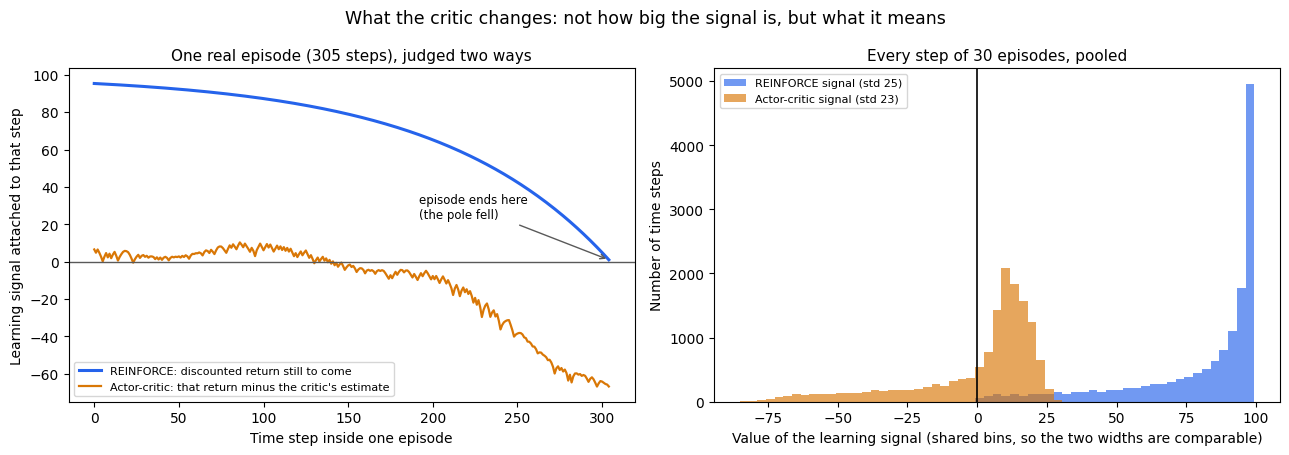

In [7]:
# Closing figure: the one thing the critic actually changes — the NUMBER that multiplies log pi(a|s).
# No algorithms race here (this notebook deliberately does not run that comparison). We take the policy
# REINFORCE already trained above, replay it, and ask: what learning signal does each method attach to
# each step of the same real episodes?

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import torch
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Replay the trained policy on fresh episodes and record every state and every reward.
# We keep collecting until at least one episode ends with the pole actually falling, because
# an episode that merely hit the 500-step cut-off has a different story to tell.
episode_states, episode_returns, episode_ended_by_falling = [], [], []
for _ in range(40):
    obs, _ = env.reset()
    states, rewards = [], []
    for _ in range(500):
        with torch.no_grad():
            action_probs = policy(torch.tensor(obs).float().unsqueeze(0))
        action = int(torch.distributions.Categorical(action_probs).sample())
        states.append(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        rewards.append(reward)
        if terminated or truncated:
            break
    # Discounted return still to come from each step: exactly the signal REINFORCE uses.
    running, returns_to_go = 0.0, []
    for reward in reversed(rewards):
        running = reward + GAMMA * running
        returns_to_go.insert(0, running)
    episode_states.append(np.array(states))
    episode_returns.append(np.array(returns_to_go))
    episode_ended_by_falling.append(bool(terminated))
    if len(episode_returns) >= 30 and any(episode_ended_by_falling):
        break

# Pool every step of every episode into one training set for the critic.
all_states = torch.tensor(np.concatenate(episode_states)).float()
all_returns = torch.tensor(np.concatenate(episode_returns)).float()

# Train ONLY the critic side of the ActorCritic class from Part 1: predict the return from the state.
# That is the critic's whole job — no actions, no policy, just "how good does this situation look?".
critic_model = ActorCritic()
critic_opt = optim.Adam(list(critic_model.shared.parameters())
                        + list(critic_model.critic_head.parameters()), lr=1e-2)
for _ in range(300):
    _, predicted = critic_model(all_states)
    critic_loss = ((predicted.squeeze() - all_returns) ** 2).mean()
    critic_opt.zero_grad(); critic_loss.backward(); critic_opt.step()

# The two learning signals, over exactly the same steps.
with torch.no_grad():
    _, all_values = critic_model(all_states)
advantage = (all_returns - all_values.squeeze()).numpy()
returns_np = all_returns.numpy()

print(f"Collected {len(episode_returns)} episodes, {len(returns_np)} time steps in total.")
print(f"REINFORCE signal (return still to come): mean {returns_np.mean():6.1f}  std {returns_np.std():5.1f}  "
      f"positive at {100 * (returns_np > 0).mean():.0f}% of steps")
print(f"Actor-critic signal (return - critic):   mean {advantage.mean():6.1f}  std {advantage.std():5.1f}  "
      f"positive at {100 * (advantage > 0).mean():.0f}% of steps")

# Pick one episode to show step by step; prefer one where the pole really fell.
fallen = [i for i, fell in enumerate(episode_ended_by_falling) if fell]
pick = fallen[0] if fallen else int(np.argmin([len(r) for r in episode_returns]))
pick_states = torch.tensor(episode_states[pick]).float()
pick_returns = episode_returns[pick]
with torch.no_grad():
    _, pick_values = critic_model(pick_states)
pick_advantage = pick_returns - pick_values.squeeze().numpy()
ending = "the pole fell" if episode_ended_by_falling[pick] else "the 500-step cut-off"
print(f"Left panel shows episode #{pick}: {len(pick_returns)} steps, ended by {ending}.")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

# ---- Panel 1: the same episode, judged two ways, step by step (time is ordered, so lines are honest here).
ax = axes[0]
steps = np.arange(len(pick_returns))
ax.plot(steps, pick_returns, lw=2.2, color="#2563eb",
        label="REINFORCE: discounted return still to come")
ax.plot(steps, pick_advantage, lw=1.6, color="#d97706",
        label="Actor-critic: that return minus the critic's estimate")
ax.axhline(0.0, color="0.35", lw=1.0)
ax.annotate(f"episode ends here\n({ending})", xy=(len(steps) - 1, pick_returns[-1]),
            xytext=(0.62, 0.55), textcoords="axes fraction", fontsize=8.5,
            arrowprops=dict(arrowstyle="->", color="0.35"))
ax.set_xlabel("Time step inside one episode")
ax.set_ylabel("Learning signal attached to that step")
ax.set_title(f"One real episode ({len(steps)} steps), judged two ways", fontsize=11)
ax.legend(fontsize=8, loc="lower left")

# ---- Panel 2: every step of every episode, both signals in the SAME bins so the widths are comparable.
ax = axes[1]
edges = np.linspace(min(returns_np.min(), advantage.min()), max(returns_np.max(), advantage.max()), 60)
ax.hist(returns_np, bins=edges, alpha=0.65, color="#2563eb",
        label=f"REINFORCE signal (std {returns_np.std():.0f})")
ax.hist(advantage, bins=edges, alpha=0.65, color="#d97706",
        label=f"Actor-critic signal (std {advantage.std():.0f})")
ax.axvline(0.0, color="black", lw=1.2)
ax.set_xlabel("Value of the learning signal (shared bins, so the two widths are comparable)")
ax.set_ylabel("Number of time steps")
ax.set_title(f"Every step of {len(episode_returns)} episodes, pooled", fontsize=11)
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("What the critic changes: not how big the signal is, but what it means", fontsize=12.5)
plt.tight_layout()
plt.show()

### 👁️ Read the figure

**What you are looking at.** Both panels show the *same* trained policy on the *same* real episodes; only the
number used to judge each step changes. Blue is what REINFORCE multiplies `log pi(a|s)` by — the discounted
reward still to come after that step. Orange is what an actor-critic multiplies it by — that same return minus
the critic's prediction of it. Left: one episode, step by step. Right: every step of all the episodes, dropped
into one set of shared bins so the two widths can be compared directly.

**What to see.** Start with the blue histogram on the right: it sits entirely to the right of the black zero
line. Every action the agent took gets pushed **up**, because on CartPole every return is positive — REINFORCE
can only argue about *how much* to encourage an action, never about whether to discourage it. The orange
histogram straddles zero: roughly a third of the steps come out negative, and those actions get pushed down.
Now the left panel, where the same fact plays out inside one episode: the blue line just counts the clock down
towards the end, nearly identical for a good step and a bad one at the same moment, while the orange line
hovers near zero early and then dives — the critic saying "from here on, this went worse than I expected",
which is exactly where this episode was heading for the floor.

**What it proves.** Two things, and the second one is the honest half. First: the critic converts an
unsigned "how long did the episode last" into a signed "better or worse than expected", per step. That is the
AlphaStar argument in miniature — credit the move, not the final score. Second: look at the two standard
deviations in the legend. They are nearly the same. On CartPole the critic barely narrows the signal at all,
which is precisely what "Where this breaks" says below — short episodes, dense reward, and a normalised-return
baseline already does most of the job. The critic earns its keep when the horizon is long and the reward is
rare, not on a 500-step pole.

## ⚠️ Where this breaks

**The assumption that has to hold:** the critic's estimate is good enough that the actor should
believe it. Actor-critic replaces one large, honest variance with a smaller, biased signal — and a
biased signal is a *systematic* error, not a noisy one.

- **You are now training two things that depend on each other.** The actor learns from the critic;
  the critic learns from data the actor generates. Both have learning rates. Get the ratio wrong and
  the pair oscillates or collapses, and the training curve gives you no clue which half is at fault.
- **A confidently wrong critic is worse than none.** If the critic overvalues a region of state
  space, the actor will move there, generate more data confirming it, and both will agree. That is a
  feedback loop, and it does not announce itself as an error.
- **Three episodes is not evidence.** This notebook's actor-critic cell is a smoke test. The general
  version of that warning is Unit 3, lesson 05 and Unit 4, lesson 05: single short runs of RL
  algorithms routinely produce results that a rerun reverses.
- **Still on-policy.** Vanilla actor-critic reuses data no better than REINFORCE does. PPO in the
  next lesson is largely about getting several gradient steps out of one batch without the policy
  running away.
- **Cheaper alternative:** for short episodes with dense rewards — CartPole is exactly this —
  REINFORCE with a normalised-return baseline is simpler, has one learning rate, and will often match
  actor-critic. The critic earns its complexity when the horizon is long and the reward is sparse,
  which is why StarCraft needed it and a 500-step pole does not.


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines actor-critic exactly as it is taught above. This box says where that technique sits on the 2026 map.*

The critic is the part of this lesson that current practice most often deletes. In language-model post-training — reinforcement learning's highest-profile use in 2025-26 — the workhorse is **GRPO** (Shao, Wang, Zhu *et al.*, *DeepSeekMath*, 2024): instead of training a value network to say how good the current state is, it samples a *group* of answers to the same prompt and uses that group's mean return as the baseline, removing the critic and its second learning rate along with it. DeepSeek-R1 (DeepSeek-AI, 2025, *Nature* 645, 633-638; arXiv:2501.12948) trained its long reasoning behaviour this way. A further step removes the reinforcement-learning loop entirely: **Direct Preference Optimization** (Rafailov *et al.*, 2023) shows that a policy fitted to preference pairs is already its own implicit reward model, so no actor, no critic and no separate reward model need to be trained at all. What none of that changes is the trade this notebook puts in front of you — a lower-variance but biased learning signal in place of an unbiased, noisy one. A group baseline is only recognisable *as* a baseline once you have written the actor-critic update yourself and watched the advantage take the place of the raw return, which is why this lesson comes first and why the official plan examines it.

**Read:** Rafailov *et al.* (2023), <https://arxiv.org/abs/2305.18290> · Shao, Wang, Zhu *et al.* (2024), <https://arxiv.org/abs/2402.03300> (entries 5-6 in this lesson's 📚 References).

---


## Closing Takeaway

**Teaching takeaway:** Actor-critic methods combine a policy learner with a value-based guide so each part supports the other during training.

**If students remember one idea:** The actor decides what to do, while the critic evaluates how good the decision appears to be.

**Quick check before moving on:**
- Can you explain the separate jobs of the actor and the critic?
- Can you describe why the critic can reduce variance in policy learning?

**Bridge to the next step:** This prepares students for PPO, which adds practical constraints that make policy optimization more stable.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
